In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
train_dir = "/content/drive/MyDrive/AI and ML/Week 5/FruitinAmazon/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI and ML/Week 5/FruitinAmazon/FruitinAmazon/test"

Task 1 — Visualize one random image from each class

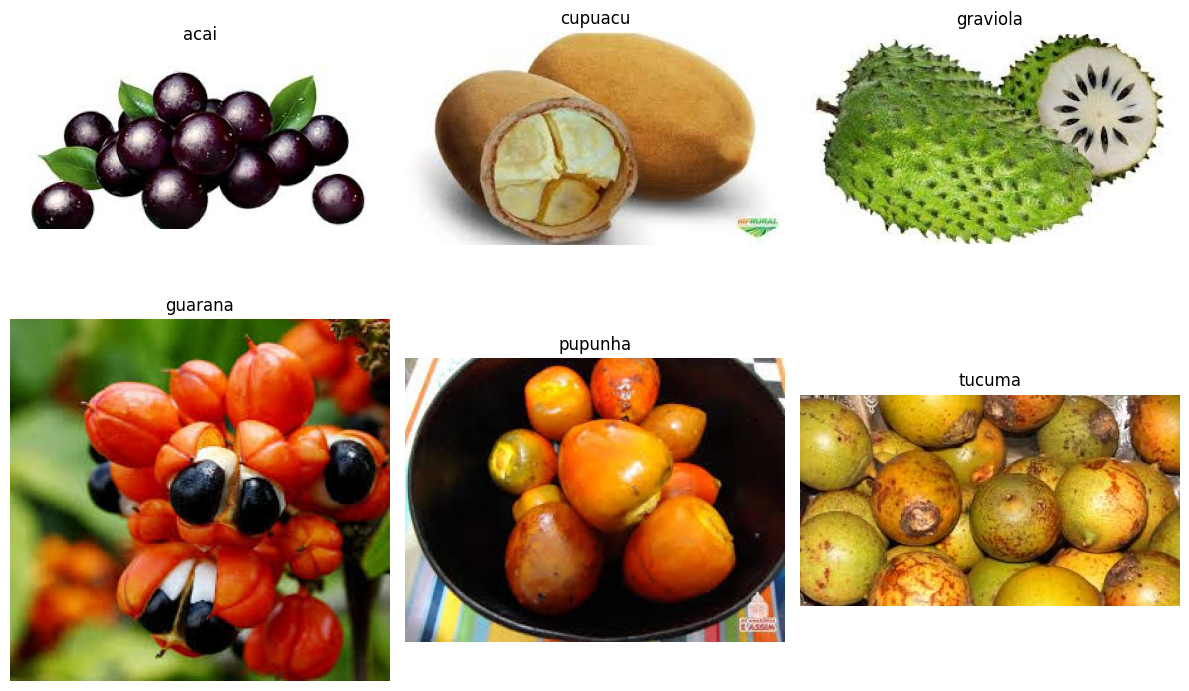

In [6]:
import os
import random
import math
import matplotlib.pyplot as plt
from PIL import Image

classes = sorted(os.listdir(train_dir))

sample_images = []
sample_labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    if os.path.isdir(class_path):
        image_files = os.listdir(class_path)
        if len(image_files) > 0:
            img_name = random.choice(image_files)
            img_path = os.path.join(class_path, img_name)
            sample_images.append(img_path)
            sample_labels.append(cls)

num_images = len(sample_images)
cols = math.ceil(num_images / 2)

plt.figure(figsize=(4 * cols, 8))

for i, img_path in enumerate(sample_images):
    img = Image.open(img_path)
    plt.subplot(2, cols, i + 1)
    plt.imshow(img)
    plt.title(sample_labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Observation:
The dataset contains different fruit categories stored in separate class folders. The sample images show clear differences in color, texture, and shape, although some classes may still look visually similar. Backgrounds, lighting, and fruit orientation vary across images, which can make the classification task more challenging.

Task 2 — Check and remove corrupted images

In [7]:
from PIL import Image

corrupted_images = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for file_name in os.listdir(class_path):
            image_path = os.path.join(class_path, file_name)
            try:
                with Image.open(image_path) as img:
                    img.verify()
            except (IOError, SyntaxError, OSError):
                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print(f"Total corrupted images removed: {len(corrupted_images)}")

No Corrupted Images Found.


In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report

img_height = 128
img_width = 128
batch_size = 16
seed = 123

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="int"
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="int"
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Class names:", class_names)
print("Number of classes:", num_classes)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    label_mode="int"
)

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6
Found 30 files belonging to 6 classes.


Task 3 - Build the CNN model

In [9]:
model = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

Task 4 — Compile the model

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step - accuracy: 0.1872 - loss: 2.0122
Epoch 1: val_accuracy improved from None to 0.27778, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - accuracy: 0.1806 - loss: 2.0137 - val_accuracy: 0.2778 - val_loss: 1.8582
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.3184 - loss: 1.7544
Epoch 2: val_accuracy did not improve from 0.27778
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step - accuracy: 0.3472 - loss: 1.7368 - val_accuracy: 0.0556 - val_loss: 1.8671
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.1965 - loss: 1.6432
Epoch 3: val_accuracy did not improve from 0.27778
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 281ms/step - accuracy: 0.2639 - loss: 1.6009 - val_accuracy: 0.1667 - val_loss: 1.7546
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step - accuracy: 0.3833 - loss: 1.3717
Epoch 4: val_accuracy did not improve from 0.27778
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 375ms/step - accuracy: 0.4167 - loss: 1.3353 - val_accuracy: 0.2778 - val_loss: 1.7808
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.7851 - loss: 0.992


Epoch 5: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 281ms/step - accuracy: 0.7639 - loss: 0.9897 - val_accuracy: 0.3889 - val_loss: 1.5783
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.7465 - loss: 0.6876
Epoch 6: val_accuracy did not improve from 0.38889
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 207ms/step - accuracy: 0.7639 - loss: 0.6779 - val_accuracy: 0.3889 - val_loss: 2.4645
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.7910 - loss: 0.6098
Epoch 7: val_accuracy did not improve from 0.38889
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 217ms/step - accuracy: 0.7778 - loss: 0.6511 - val_accuracy: 0.3889 - val_loss: 1.6723
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.9490 - loss: 0.3007
Epoch 8: val_accuracy improved from 0.38889 to 0.44444, saving model to best_model.h5



Epoch 8: finished saving model to best_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 269ms/step - accuracy: 0.9583 - loss: 0.2963 - val_accuracy: 0.4444 - val_loss: 1.6726
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.9771 - loss: 0.2324
Epoch 9: val_accuracy did not improve from 0.44444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - accuracy: 0.9583 - loss: 0.2404 - val_accuracy: 0.2222 - val_loss: 2.1719
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.9882 - loss: 0.0929
Epoch 10: val_accuracy did not improve from 0.44444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - accuracy: 0.9722 - loss: 0.1051 - val_accuracy: 0.2778 - val_loss: 1.9159
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step - accuracy: 0.9736 - loss: 0.0749
Epoch 11: val_accuracy did not improve from 0.44444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 332ms/step - accuracy: 0.9722 - loss: 0.0733 - val_accuracy: 0.4444 - val_loss: 2.0995
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 1.0000 - loss: 

Accuracy Graph

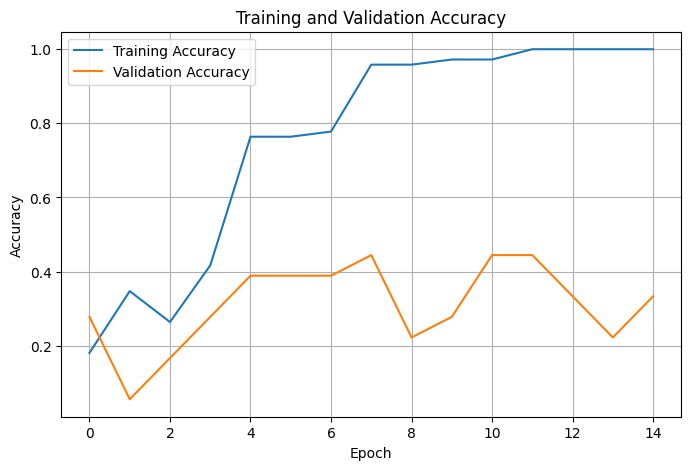

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Loss Graph

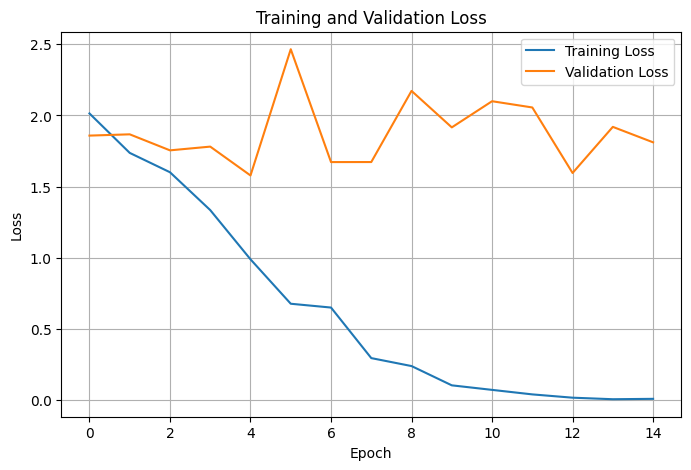

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

Task 5 — Evaluate on test set

In [13]:
test_loss, test_accuracy = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.4000 - loss: 1.2063
Test Loss: 1.2063488960266113
Test Accuracy: 0.4000000059604645


Task 6 - Save the model

In [26]:
model.save("/content/drive/MyDrive/AI and ML/Week 5/FruitinAmazon/FruitinAmazon/fruit_cnn_model.h5")
print("Model saved successfully.")

Model saved successfully.


In [27]:
loaded_model = tf.keras.models.load_model("/content/drive/MyDrive/AI and ML/Week 5/FruitinAmazon/FruitinAmazon/fruit_cnn_model.h5")

In [28]:
loaded_loss, loaded_accuracy = loaded_model.evaluate(test_ds)
print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.4000 - loss: 1.2063
Loaded Model Test Loss: 1.2063488960266113
Loaded Model Test Accuracy: 0.4000000059604645


Task 7 — Predict on test data

In [29]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step


In [30]:
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

              precision    recall  f1-score   support

        acai       0.36      1.00      0.53         5
     cupuacu       1.00      0.20      0.33         5
    graviola       1.00      0.20      0.33         5
     guarana       0.00      0.00      0.00         5
     pupunha       0.45      1.00      0.62         5
      tucuma       0.00      0.00      0.00         5

    accuracy                           0.40        30
   macro avg       0.47      0.40      0.30        30
weighted avg       0.47      0.40      0.30        30



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


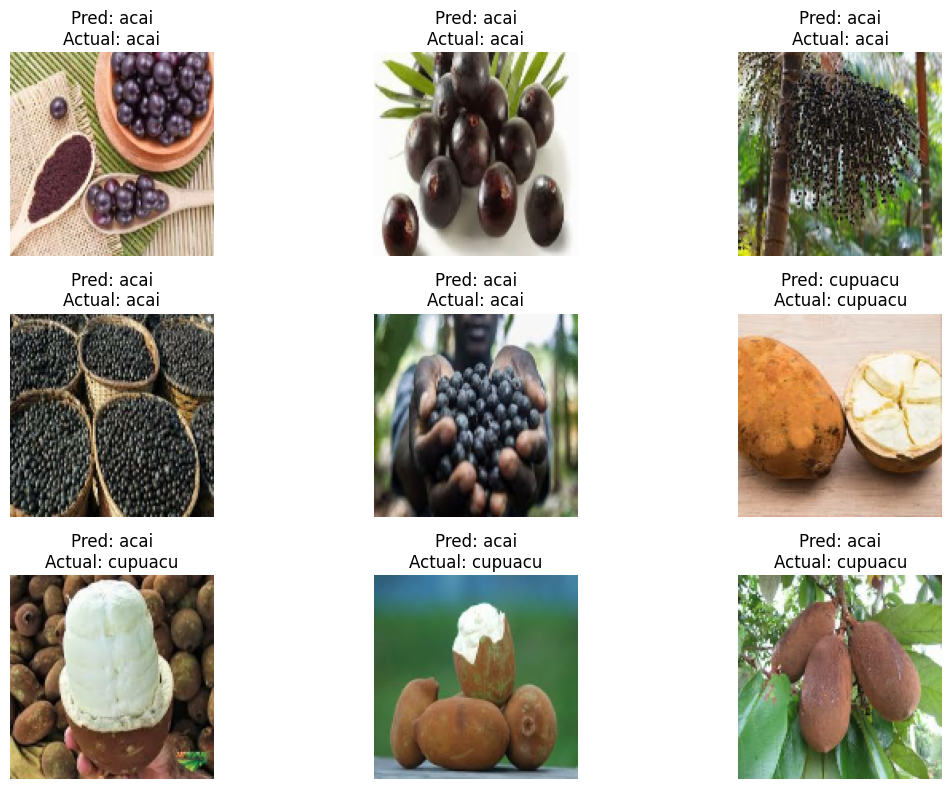

In [31]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    for i in range(min(9, len(images))):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(f"Pred: {class_names[predicted_labels[i]]}\nActual: {class_names[labels[i]]}")
        plt.axis("off")

plt.tight_layout()
plt.show()